https://www.perplexity.ai/search/you-are-a-python-instructor-fo-D8PzUjQ8SEC1obKOCCZ2vg#10

# Bioinformatics Breast Cancer Classification 

This notebook demonstrates bioinformatics-style data analysis on a publicly available cancer dataset.
We simulate machine learning principles commonly applied to bioinformatics datasets using the Breast Cancer Wisconsin dataset as an example.

Steps include:
- Loading the dataset from an online repository.
- Exploring and visualizing feature patterns.
- Performing principal component analysis (PCA) for dimensionality reduction.
- Building a logistic regression classifier.

The analysis integrates bioinformatics techniques (feature variance exploration and clustering) with standard Python data science libraries.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

sns.set(style='whitegrid', context='notebook')

## 1. Load and Inspect Online Dataset

We will load the **Breast Cancer Wisconsin Diagnostic dataset** hosted online.     
This dataset contains numerical features measured from biopsies.

### Function: `pd.read_csv(url)`
- `url`: direct link to a CSV dataset.
- `header`: row number(s) for headers.
- `index_col`: optional column to use as row labels.


In [6]:
url = 'https://gist.githubusercontent.com/adameubanks/35a6beea49e5b9ba62797e595a9626c0/raw/8974e055bdf3a9d7e6cacf1c1c30fcfd2ffd6de3/cancer.csv'
data = pd.read_csv(url)

data = data.rename(columns = {"diagnosis(1=m, 0=b)":"diagnosis"})
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Data Exploration

We examine the basic dataset structure and statistical description.

### Methods Used:
- `.info()`: displays data structure.
- `.describe()`: computes summary statistics.
- `.value_counts()`: tallies categorical occurrences of target labels.


In [7]:
print(data.info())
display(data.describe())
print('\nClass distribution:')
print(data['diagnosis'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Class distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


## 3. Feature Correlation and Visualization

Gene expression‑like data often exhibit feature co-expression or redundancy.

### Visualization Functions
- `DataFrame.corr()` computes correlation coefficients between all numerical features.
- `sns.heatmap()` visualizes these correlations. Parameters:
  - `annot=True` displays correlation values.
  - `cmap='viridis'` chooses a perceptually uniform colormap.
  - `center`: sets the midpoint of the color map.


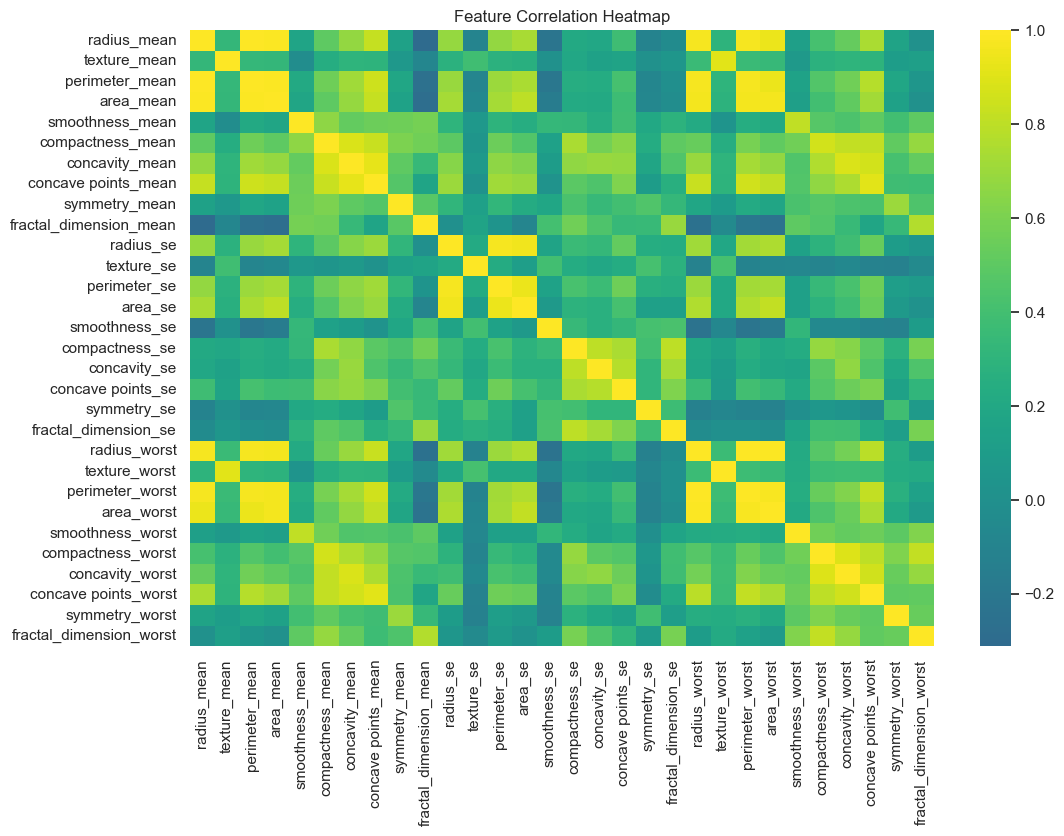

In [8]:
corr = data.drop('diagnosis', axis=1).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='viridis', center=0, annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

## 4. Dimensionality Reduction using PCA

Principal Component Analysis (PCA) projects high-dimensional gene data into fewer components to capture most variance.

### Steps and Parameters:
- `StandardScaler().fit_transform(X)` scales data such that each feature has mean 0 and standard deviation 1.
- `PCA(n_components)` reduces dimensions.
  - `n_components`: number of principal axes to extract (e.g., 2 for visualization).
- `.fit_transform(X_scaled)`: computes principal components.

We visualize PCA scores in 2D colored by cancer diagnosis.

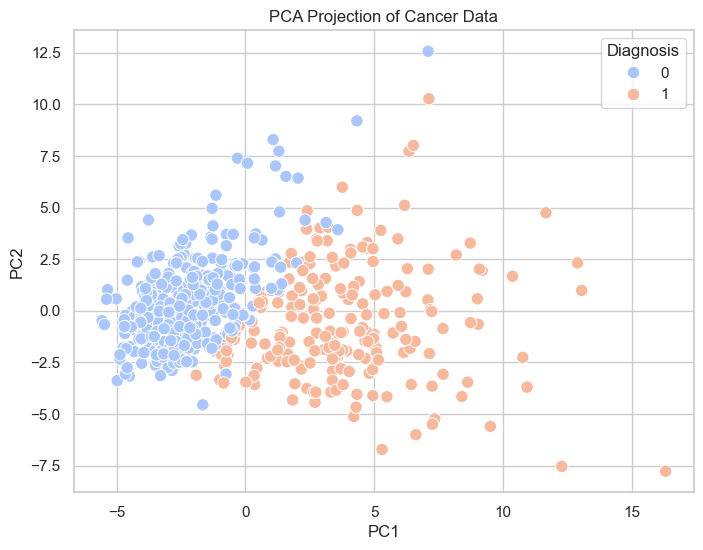

Explained variance by first two PCs: [0.443 0.19 ]


In [9]:
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Diagnosis'] = y.values

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Diagnosis', data=pca_df, s=80, palette='coolwarm')
plt.title('PCA Projection of Cancer Data')
plt.show()

print('Explained variance by first two PCs:', np.round(pca.explained_variance_ratio_, 3))

## 5. Classification: Logistic Regression Model

We train a logistic regression classifier on the standardized data.

### Function and Parameter Explanations
- `train_test_split(X, y, test_size=0.3, random_state=42)`:
  - Splits data into training (70%) and test (30%) sets.
- `LogisticRegression(solver='lbfgs', max_iter=1000)`:
  - `solver`: optimization algorithm.
  - `max_iter`: prevents convergence issues.
- `.fit(X_train, y_train)`: fits model to training data.
- `.predict(X_test)`: outputs class predictions.
- `classification_report(y_true, y_pred)`:
  - Reports precision, recall, F1-score.
- `confusion_matrix(y_true, y_pred)`:
  - Displays actual vs predicted results.


              precision    recall  f1-score   support

           0       0.99      0.98      0.99       108
           1       0.97      0.98      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



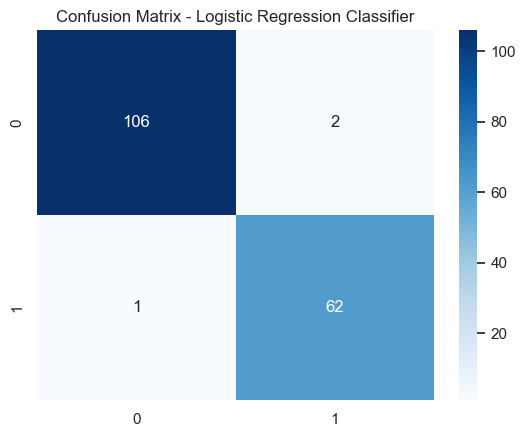

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
logit = LogisticRegression(solver='lbfgs', max_iter=1000)
logit.fit(X_train, y_train)
y_pred = logit.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression Classifier')
plt.show()

## 6. Interpretation and Bioinformatics Perspective

- **Feature correlation heatmaps** help detect co-expressed or redundant variables (genes).
- **PCA visualization** shows separability between diagnostic groups, akin to clustering of expression profiles.
- **Regression analysis** estimates linear boundaries for classification.
- **Precision and recall** indicate model reliability in detecting cancer vs non-cancer.
- These techniques parallel workflows in RNA-Seq analysis or microarray feature exploration.
